## LDA (Linear Discriminant Analysis)
선형판별 분석법

- PCA의 목적은 데이터의 분산을 최대화하면서 고차원 데이터를 저차원으로 축소하는 것이고, LDA의 목적은 클래스 간의 분리를 최대화하면서 차원을 축소하는 것이다.
- 각 클래스를 최대한 분리하도록 데이터를 선형적으로 변환하는 것이다.
- 따라서 목적이 다르므로 PCA와 LDA의 차원 축소 결과는 다르게 나온다.
- LDA는 target도 함께 제공하므로 지도학습에 해당한다.

**n_components 주의사항**
- LDA는 클래스 간의 차이를 최대화하기 위해 차원 축소를 수행한다. 따라서, 사용할 수 있는 최대 차원 수는 클래스 수보다 1개 적어야 한다.
- 또한, 사용할 수 있는 차원 수는 원래 특성 수보다 많을 수 없다.
- 즉 min(클래스 수 - 1, 특성 수)가 최대 차원 수가 된다.

![이미지출처: https://apsl.tech/en/blog/using-linear-discriminant-analysis-lda-data-explore-step-step/](https://d.pr/i/hI0WaD+)

**LDA(Linear Discriminant Analysis)의 처리 과정**

LDA는 **클래스를 가장 잘 구분할 수 있는 직선 방향**을 찾는 것이 목적이다.

* **클래스 간 거리는 멀어지고**,
* **클래스 내부 데이터는 뭉치도록**
  하는 방향 벡터 **w**를 구하는 것이 핵심이다.

**1. 클래스별 평균 벡터 (클래스 중심점) 계산**

* 예를 들어 클래스가 두 개라고 하자: 클래스 1과 클래스 2
* 각 클래스의 평균 벡터 $\mu_1$, $\mu_2$는 다음처럼 계산한다:

$$
\mu_1 = \frac{1}{N_1} \sum_{x_i \in \text{class 1}} x_i \quad,\quad
\mu_2 = \frac{1}{N_2} \sum_{x_i \in \text{class 2}} x_i
$$

* 즉, 각 클래스의 데이터 포인트들의 평균값 (벡터 평균)

**2. 클래스 내 분산 (Within-class scatter matrix) 계산**

* 각 클래스의 내부 흩어짐(분산)을 먼저 계산한다.

$$
S_i = \sum_{x \in \text{class } i} (x - \mu_i)(x - \mu_i)^T
$$

* 이걸 두 클래스에 대해 각각 계산해서 더한다:

$$
S_W = S_1 + S_2
$$

* 즉, 전체 클래스 내부의 분산을 더한 값이 **Within-class scatter matrix**, $S_W$이다.

> 이 값은 **작아야** 한다. → 투영했을 때 클래스 내부의 포인트들이 서로 가까워져야 하기 때문

**3. 클래스 간 분산 (Between-class scatter matrix) 계산**

* 두 클래스 중심점의 차이를 이용한다:

$$
S_B = (\mu_1 - \mu_2)(\mu_1 - \mu_2)^T
$$

* 이는 클래스 중심 간의 거리를 나타낸다.
* **클래스 간 차이는 커야 한다.**

> 이 값은 **커져야** 한다. → 투영했을 때 클래스끼리 서로 멀리 떨어져 있어야 함

**4. 최적의 방향 벡터 계산**

* 목표는 아래의 식처럼 **Between-class scatter를 최대화**하고, **Within-class scatter를 최소화**하는 $w$를 찾는 것:

$$
w = S_W^{-1}(\mu_1 - \mu_2)
$$

* 직관적으로,
  * $\mu_1 - \mu_2$: 클래스 간의 중심 거리 방향
  * $S_W^{-1}$: 클래스 내부 분산이 적은 쪽을 선호하도록 가중치 조절

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True, as_frame=True)

X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 최대 차원 수는 min(클래스수 - 1, 원래 특성 수)
lda = LinearDiscriminantAnalysis(n_components=2)

# 4개의 축이 2개의 축으로 변경(차원 축소)
X_lda = lda.fit_transform(X, y)

X_lda_df = pd.DataFrame(X_lda, columns=['lda1', 'lda2'])

X_lda_df['target'] = y

X_lda_df

,lda1,lda2,target
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0
...,...,...,...
145,-5.645003,-1.677717,2
146,-5.179565,0.363475,2
147,-4.967741,-0.821141,2
148,-5.886145,-2.345091,2


In [4]:
# LDA로 차원을 줄인 데이터가 실제로 클래스 구분에 도움이 되는지 확인
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, x_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=42, stratify=y)

rf_clf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf_clf, X_train, y_train, cv=5)
print(scores, "->", np.mean(scores))

[0.95833333 0.95833333 0.95833333 0.95833333 1.        ] -> 0.9666666666666668


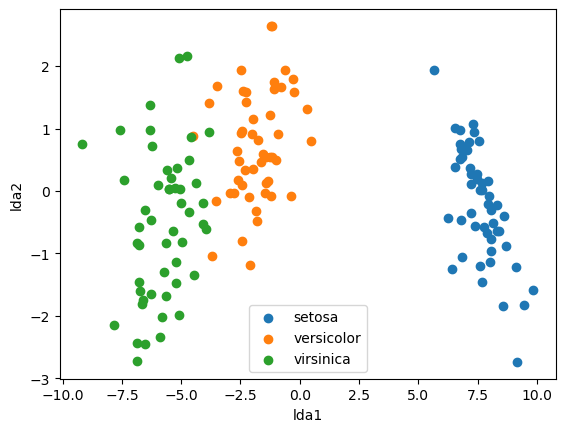

In [5]:
# 시각화

plt.scatter(
    X_lda_df[X_lda_df['target'] == 0]['lda1'],
    X_lda_df[X_lda_df['target'] == 0]['lda2'],
    label="setosa"
)

plt.scatter(
    X_lda_df[X_lda_df['target'] == 1]['lda1'],
    X_lda_df[X_lda_df['target'] == 1]['lda2'],
    label="versicolor"
)

plt.scatter(
    X_lda_df[X_lda_df['target'] == 2]['lda1'],
    X_lda_df[X_lda_df['target'] == 2]['lda2'],
    label="virsinica"
)

plt.xlabel("lda1")
plt.ylabel("lda2")
plt.legend()
plt.show()